In [1]:
import numpy as np
import pandas as pd

from geopy.geocoders import Nominatim

from math import radians, cos, sin, asin, sqrt
import googlemaps
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import random

In [2]:
yerevan_historical = pd.read_excel('../database/raw_data/Yerevan historical.xlsx')

In [3]:
yerevan_historical = yerevan_historical[(yerevan_historical['backup_status'] == "sold") & ((yerevan_historical['rent_or_sale'] == "sale appartments") | (yerevan_historical['rent_or_sale'] == "sale houses"))]
yerevan_historical['date'] = pd.to_datetime(yerevan_historical['date'], format='%Y-%m-%d')

In [4]:
houses_filt = yerevan_historical.dropna(subset=['price'])

In [5]:
filtered_df = houses_filt.loc[houses_filt.groupby('id')['date'].idxmax()].reset_index(drop=True)

## Region categories

In [ ]:
data = filtered_df.copy()

In [ ]:
geolocator = Nominatim(user_agent="my_application")

count = 0
yerevan_districts = pd.DataFrame(columns=['x', 'y', 'district'])

import pandas as pd

# Create an empty DataFrame to store the results


def get_district(lat, lng):
    # Reverse geocode the coordinates to get the address
    location = geolocator.reverse(f"{lat}, {lng}", timeout=None)
    # Extract the district information from the address
    address = location.raw['address']
    district = address.get('suburb', address.get('city_district'))
    return district

In [ ]:
while True:
    try:
        for i, row in data.iterrows():
            # Calculate the district for the current row
            district = get_district(row['x'], row['y'])
            count = count + 1
            data.drop(index=data.index[0], axis=0, inplace=True)
            # Append the current row to the new DataFrame
            yerevan_districts = yerevan_districts.append({'x': row['x'], 'y': row['y'], 'district': district}, ignore_index=True)
    except:
        # if there was an error, print a message and try again
        print("An error occurred. Retrying...")
        continue
    else:
        # if there was no error, break out of the loop and continue with the rest of the code
        break

An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...
An error occurred. Retrying...


In [ ]:
armenian_to_english = {'Աջափնյակ': 'Achapnyak',
                       'Նոր Նորք': 'Nor_Nork',
                       'Արաբկիր': 'Arabkir',
                       'Կենտրոն': 'Kentron',
                       'Դավթաշեն': 'Davtashen',
                       'Էրեբունի': 'Erebuni',
                       'Շենգավիթ': 'Shengavit',
                       'Քանաքեռ-Զեյթուն': 'Qanaqer_Zeytun',
                       'Մալաթիա-Սեբաստիա': 'Malatia_Sebastia',
                       'Ավան': 'Avan',
                       'Նոր Նորքի 1-ին զանգված': 'Nor_Nork',
                       'Նոր Նորքի 2-րդ զանգված': 'Nor_Nork',
                       'Դավթաշեն գյուղ': 'Davtashen',
                       'Նորք Մարաշ': 'Norq_Marash',
                       'Գլենդել Հիլզ': 'Kentron',
                       'Նուբարաշեն': 'Nubarashen',
                       'Հաղթանակ': 'Malatia_Sebastia',
                       'Նոյ թաղամաս': 'Malatia_Sebastia',
                       'Մուշ թաղամաս': 'Malatia_Sebastia',
                       'Էկո քաղաք': 'Achapnyak'}

yerevan_districts['district'] = yerevan_districts['district'].replace(armenian_to_english)

In [ ]:
filtered_df["district"] = yerevan_districts["district"]

In [ ]:
filtered_df = filtered_df.dropna(subset=['district']).reset_index(drop=True)
filtered_df_copy = filtered_df.copy()

In [5]:
filtered_df.to_csv("../database/yerevan_historical_clean/Yerevan_Historical_sales.csv", index=False)

In [45]:
filtered_df = pd.read_csv("../database/yerevan_historical_clean/Yerevan_Historical_sales.csv")

## Outlier detection

(0.0, 2000000.0)

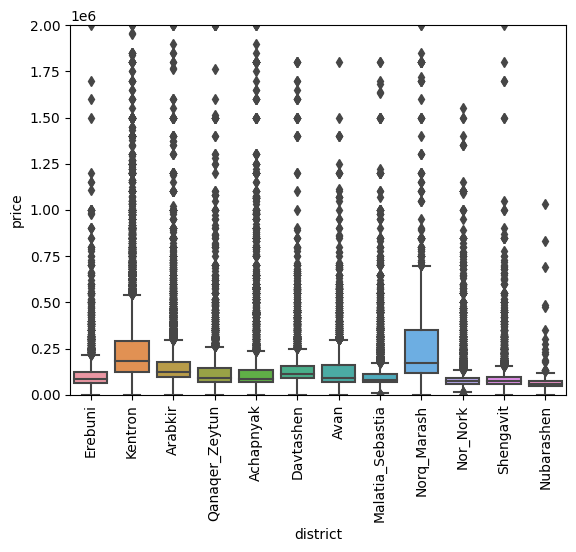

In [3]:
sns.boxplot(x='district', y='price', data=filtered_df)
plt.xticks(rotation=90)
plt.ylim(0, 2000000)

## Z-Score

In [ ]:
# from scipy import stats

# # read in the data
# #df = pd.read_csv('data.csv')

# # group the data by district
# grouped_data = filtered_df_copy.groupby('district')

# # loop over each group and calculate the Z-score for price
# for name, group in grouped_data:
#    # print(group["district"])
#     z = np.abs(stats.zscore(group['price']))
#     # print(z)
#     threshold = 1
#     outliers = group[z > threshold]
    
#     num_outliers = len(outliers)
#     print(f"District {name} has {num_outliers} outliers")
#     # filtered_df_copy = filtered_df_copy.drop(outliers.index)

In [47]:
filtered_df['square_meters'] = filtered_df['square_meters'].replace(0, None)
filtered_df['square_meters'] = filtered_df['square_meters'].astype(float)

In [48]:
for index, row in filtered_df.iterrows():
    if np.isnan(row['price_per_meter']):
        continue
    else:
        # print(row['price'] / row['price_per_meter'])
        filtered_df.loc[index, 'square_meters'] = row['price'] / row['price_per_meter']
        

In [49]:
for index, row in filtered_df.iterrows():
    if np.isnan(row['square_meters']):
        continue
    else:
        filtered_df.loc[index, 'price_per_meter'] = row['price'] / row['square_meters']

## IQR

In [54]:
grouped_data = filtered_df.groupby('district')

for name, group in grouped_data:
    q1 = group['price'].quantile(0.25)
    # print(q1)
    q3 = group['price'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = max(q1 - 1.5 * iqr, 5000)
    # print(lower_bound)
    upper_bound = q3 + 1.5 * iqr
    outliers = group[(group['price'] < lower_bound) | (group['price'] > upper_bound)]
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers")
    filtered_df = filtered_df.drop(outliers.index)

grouped_data = filtered_df.groupby('district')
for name, group in grouped_data:
    q1 = group['square_meters'].quantile(0.25)
    #print(q1)
    q3 = group['square_meters'].quantile(0.75)
    iqr = q3 - q1
    # print(lower_bound)
    lower_bound = max(q1 - 1.5 * iqr, 40)
    upper_bound = q3 + 1.5 * iqr
    outliers = group[(group['square_meters'] < lower_bound) | (group['square_meters'] > upper_bound)]
    num_outliers = len(outliers)
    print(f"District {name} has {num_outliers} outliers")
    filtered_df = filtered_df.drop(outliers.index)

District Achapnyak has 810 outliers
District Arabkir has 1391 outliers
District Avan has 402 outliers
District Davtashen has 455 outliers
District Erebuni has 392 outliers
District Kentron has 1750 outliers
District Malatia_Sebastia has 821 outliers
District Nor_Nork has 863 outliers
District Norq_Marash has 105 outliers
District Nubarashen has 23 outliers
District Qanaqer_Zeytun has 438 outliers
District Shengavit has 470 outliers
District Achapnyak has 714 outliers
District Arabkir has 1184 outliers
District Avan has 440 outliers
District Davtashen has 378 outliers
District Erebuni has 551 outliers
District Kentron has 2407 outliers
District Malatia_Sebastia has 727 outliers
District Nor_Nork has 522 outliers
District Norq_Marash has 38 outliers
District Nubarashen has 11 outliers
District Qanaqer_Zeytun has 713 outliers
District Shengavit has 913 outliers


## Haversine and Actual walking distance

In [44]:
# Define a function to calculate the Haversine distance between two points
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # Convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

def get_walking_distance(start_lon, start_lat, end_lon, end_lat):
    # Set up the Google Maps API client
    gmaps = googlemaps.Client(key='***REMOVED-GOOGLE-API-KEY***')

    # Define the start and end coordinates
    start = (start_lat, start_lon)
    end = (end_lat, end_lon)

    # Make the API request
    now = datetime.now()
    directions = gmaps.directions(start, end, mode='walking', departure_time=now)

    # Extract the distance from the response
    distance = directions[0]['legs'][0]['distance']['value']

    # Return the distance in meters
    return distance

In [45]:
# Metro Stations in Yerevan
stations = pd.DataFrame({
    'station_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'station_name': ['Barekamutyun', 'Baghramyan', 'Yeritasardakan', 'Republic Square', 'Zoravar Andranik', 'Sasuntsi Davit', 'Gortsaranain','Shengavit', 'Charbakh', 'Garegin Nzhdeh Square'],
    'x': [40.197446,40.1918167,40.1873081, 40.1785331, 40.1699272, 40.1552243, 40.1410611, 40.145224, 40.1405941, 40.1504761],
    'y': [44.493467,44.5038091, 44.5191743, 44.5134433, 44.5112603, 44.5058011, 44.4964173, 44.48483, 44.4685333, 44.4816183]
})

In [ ]:
# Loop through each house and station to find the shortest distance using Haversine
distances = []
station_ids = []
station_names = []
for house_idx, house in filtered_df.iterrows():
    shortest_distance = float('inf')
    nearest_station_name = ''
    for station_idx, station in stations.iterrows():
        distance = haversine(house['y'], house['x'], station['y'], station['x'])
        if distance < shortest_distance:
            shortest_distance = distance
            nearest_station_id = station['station_id']
            nearest_station_name = station['station_name']
    #distances.append(shortest_distance)
    station_ids.append(nearest_station_id)
    station_names.append(nearest_station_name)

# Add the new columns to the houses table
#houses['shortest_distance'] = distances
filtered_df['nearest_station_id'] = station_ids
filtered_df['nearest_station_name'] = station_names

In [57]:
houses = filtered_df.copy()

In [ ]:
# h1["closest_metro"] = houses["nearest_station_name"]
# distances = []

# Using Google Maps API to calculate the walking distance
for i, house in houses.iterrows():
    distance = get_walking_distance(house['y'], house['x'], stations['y'][house['nearest_station_id']-1], stations['x'][house['nearest_station_id']-1])
    distances.append(distance)
    houses.drop(index=houses.index[0], axis=0, inplace=True)
#houses["walk_distance"] = distances


In [84]:
filtered_df["walking_distance_to_metro(m)"] = distances

## Spatial Jittering


In [57]:
def apply_jitter(coord, distance):
    """
    Apply jitter to a coordinate (latitude or longitude).

    :param coord: Input coordinate (float)
    :param distance: Maximum distance to apply jitter (float)
    :return: jittered_coord: Jittered coordinate (float)
    """
    jittered_coord = coord + (distance * random.uniform(-1, 1))
    return jittered_coord

In [58]:
jitter_distance = 0.00001  # Adjust this value according to the desired jitter distance
filtered_df['latitude_jittered'] = filtered_df['y'].apply(lambda x: apply_jitter(x, jitter_distance))
filtered_df['longitude_jittered'] = filtered_df['x'].apply(lambda x: apply_jitter(x, jitter_distance))
grouped_data = filtered_df.groupby(['latitude_jittered', 'longitude_jittered']).size().reset_index(name='count')

sorted_grouped_data = grouped_data.sort_values('count', ascending=False)

most_frequent_coords = sorted_grouped_data.head()
print(most_frequent_coords)

       latitude_jittered  longitude_jittered  count
0              44.413063           40.170780      1
48004          44.515498           40.204272      1
48010          44.515498           40.204272      1
48009          44.515498           40.204265      1
48008          44.515498           40.204277      1


In [59]:
filtered_df.drop(columns=['OBJECTID', 'level_0', 'index', 'years_moths', 'nearest_station_id'], inplace=True)
filtered_df = filtered_df.rename(columns={'date': 'sold_date', 'nearest_station_name': 'closest_metro'})

In [60]:
filtered_df = filtered_df.reset_index(drop=True)

In [61]:
filtered_df.to_csv("../database/yerevan_historical_clean/sale_historical.csv", index=False) # without outliers